# Statistical Significance — Section 8.4

Bootstrap comparison of per-trade log-returns between Elo and Full Model (half-Kelly).

**Outputs:**

| File | Purpose |
|---|---|
| `sig_bootstrap_mean_log_returns.png` | Bootstrap distribution of mean log-return |
| `sig_bootstrap_summary_table.csv` | Mean, 95% CI, P(FM > Elo) |
| `sig_per_trade_log_return_distribution.png` | Appendix — per-trade log-return distribution |

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

%matplotlib inline
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'figure.dpi': 120})

ANALYSIS_DIR = Path('../..').resolve() / 'src' / 'srwnba' / 'analysis'
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

from outputs import save_fig, save_table
from walkforward import fit_holdout_models
from markets import build_kalshi_trading_index
from trading import collect_entries, run_kelly_ideal, add_trade_returns, BANKROLL_INIT
from eval_helpers import bootstrap_diff, bootstrap_distribution
from final_model import load_year, LABEL_COL  # type: ignore

MODEL_LABELS = {'elo': 'Elo', 'full_model': 'Full Model'}
MODEL_COLORS = {'elo': '#3498db', 'full_model': '#e74c3c'}
BEST_EDGE_MIN = 0.05
BEST_NORM_MIN = 0.25
N_BOOT = 10_000

In [2]:
# Build half-Kelly trades for both models under the same best config
preds_df, _ = fit_holdout_models(
    {'xgb_with_elo': {'type': 'xgb', 'use_bm': True}, 'elo': {'type': 'elo'}},
    holdout_year=2025,
)
model_w = preds_df[preds_df['model']=='xgb_with_elo'][['game_id','pred_prob']].rename(columns={'pred_prob':'p_full_model'})
elo_w   = preds_df[preds_df['model']=='elo'][['game_id','pred_prob']].rename(columns={'pred_prob':'p_elo'})
test_df = load_year(2025).dropna(subset=[LABEL_COL,'base_margin'])[
    ['game_id','game_ts','game_date','home_team_id','away_team_id', LABEL_COL]
].copy()
test_df['game_ts'] = pd.to_datetime(test_df['game_ts'], utc=True)
signals = test_df.merge(model_w, on='game_id').merge(elo_w, on='game_id')

idx = build_kalshi_trading_index(signals)
ticker_info, pretip = idx['ticker_info'], idx['pretip']

trades = {}
for name, col in [('elo','p_elo'), ('full_model','p_full_model')]:
    ents = collect_entries(ticker_info, pretip, col, BEST_EDGE_MIN, BEST_NORM_MIN, 'half_life')
    tdf = add_trade_returns(pd.DataFrame(run_kelly_ideal(ents, 0.5, BANKROLL_INIT)))
    trades[name] = tdf
    print(f'{name}: {len(tdf)} trades, mean log-ret {tdf["log_ret"].mean():+.4f}, terminal ${tdf["bankroll"].iloc[-1]:,.0f}')

  xgb_with_elo             best_round=88
elo: 155 trades, mean log-ret +0.0106, terminal $517
full_model: 134 trades, mean log-ret +0.0183, terminal $1,162


---
## §8.4 — Bootstrap comparison
**Figure:** `sig_bootstrap_mean_log_returns`. **Table:** `sig_bootstrap_summary_table`.

In [3]:
lr_fm  = trades['full_model']['log_ret'].values
lr_elo = trades['elo']['log_ret'].values

boot_fm  = bootstrap_distribution(lr_fm,  n_boot=N_BOOT, statistic=np.mean)
boot_elo = bootstrap_distribution(lr_elo, n_boot=N_BOOT, statistic=np.mean)
result = bootstrap_diff(lr_fm, lr_elo, n_boot=N_BOOT, statistic=np.mean)

ci_fm  = np.percentile(boot_fm,  [2.5, 97.5])
ci_elo = np.percentile(boot_elo, [2.5, 97.5])
t_stat, p_two = stats.ttest_ind(lr_fm, lr_elo, equal_var=False)
p_one = (p_two / 2) if t_stat > 0 else (1 - p_two / 2)

summary = pd.DataFrame([
    {'model': 'full_model', 'n_trades': len(lr_fm),
     'mean_log_ret': lr_fm.mean(), 'ci_lo': ci_fm[0], 'ci_hi': ci_fm[1],
     'terminal_implied': BANKROLL_INIT * np.exp(lr_fm.mean() * len(lr_fm))},
    {'model': 'elo', 'n_trades': len(lr_elo),
     'mean_log_ret': lr_elo.mean(), 'ci_lo': ci_elo[0], 'ci_hi': ci_elo[1],
     'terminal_implied': BANKROLL_INIT * np.exp(lr_elo.mean() * len(lr_elo))},
    {'model': 'difference (FM − Elo)', 'n_trades': np.nan,
     'mean_log_ret': result['diff'], 'ci_lo': result['ci_lo'], 'ci_hi': result['ci_hi'],
     'terminal_implied': np.nan, 'p_fm_gt_elo': result['p_a_gt_b'],
     'welch_t_stat': float(t_stat), 'welch_p_one_sided': float(p_one)},
])
save_table(summary, 'sig_bootstrap_summary_table')
summary

  saved: outputs\sig_bootstrap_summary_table.csv


,model,n_trades,mean_log_ret,ci_lo,ci_hi,terminal_implied,p_fm_gt_elo,welch_t_stat,welch_p_one_sided
0,full_model,134.0,0.018303,-0.010941,0.048133,1161.785792,NaN,NaN,NaN
1,elo,155.0,0.010599,-0.015928,0.038152,516.972184,NaN,NaN,NaN
2,difference (FM − Elo),NaN,0.007704,-0.032842,0.047450,NaN,0.6518,0.37642,0.353444


  saved: outputs\sig_bootstrap_mean_log_returns.png


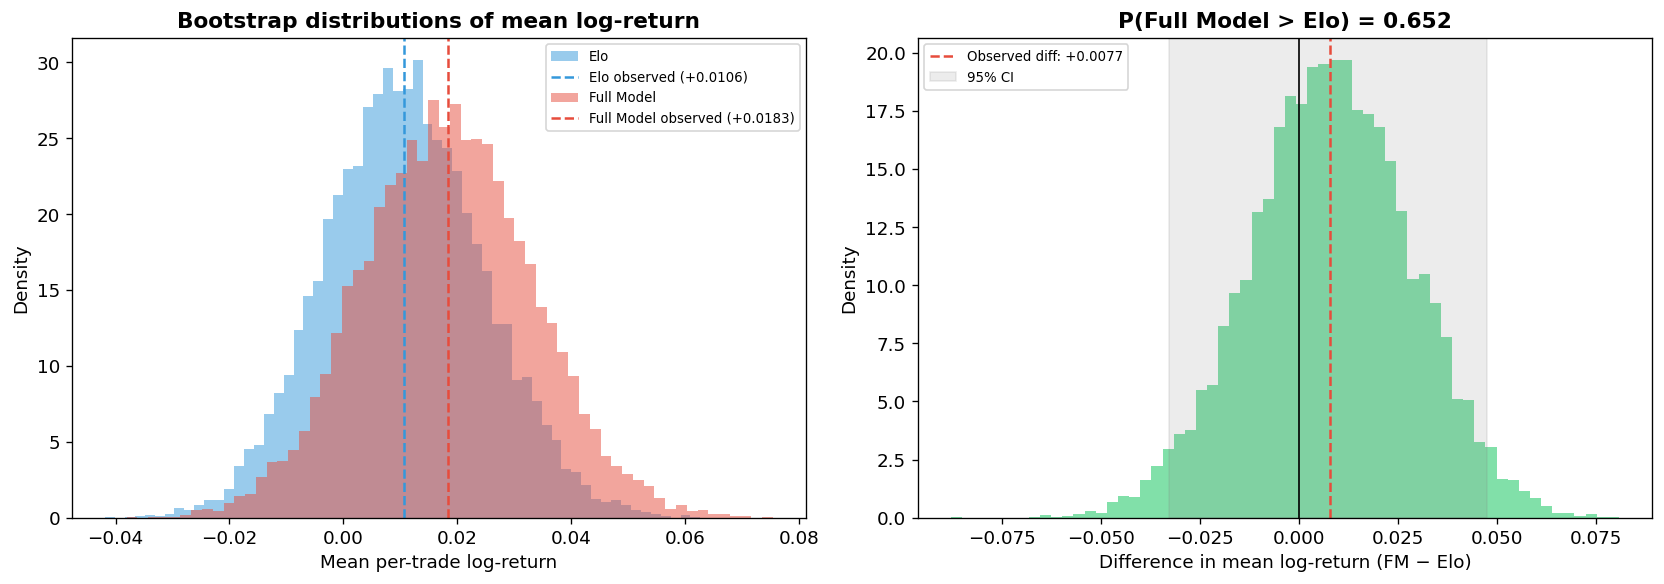

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for vals, color, label, observed in [
    (boot_elo, MODEL_COLORS['elo'],        'Elo',         lr_elo.mean()),
    (boot_fm,  MODEL_COLORS['full_model'], 'Full Model',  lr_fm.mean()),
]:
    ax.hist(vals, bins=60, alpha=0.5, color=color, density=True, label=label)
    ax.axvline(observed, color=color, ls='--', lw=1.5, label=f'{label} observed ({observed:+.4f})')
ax.set_xlabel('Mean per-trade log-return'); ax.set_ylabel('Density')
ax.set_title('Bootstrap distributions of mean log-return', fontweight='bold')
ax.legend(fontsize=8)

ax = axes[1]
ax.hist(result['diffs'], bins=60, alpha=0.6, color='#2ecc71', density=True)
ax.axvline(0, color='black', lw=1)
ax.axvline(result['diff'], color=MODEL_COLORS['full_model'], ls='--', lw=1.5,
           label=f"Observed diff: {result['diff']:+.4f}")
ax.axvspan(result['ci_lo'], result['ci_hi'], alpha=0.15, color='grey', label='95% CI')
ax.set_xlabel('Difference in mean log-return (FM − Elo)')
ax.set_ylabel('Density')
ax.set_title(f"P(Full Model > Elo) = {result['p_a_gt_b']:.3f}", fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
save_fig(fig, 'sig_bootstrap_mean_log_returns')
plt.show()

---
## §8.4 Appendix — Per-trade log-return distribution
**Figure:** `sig_per_trade_log_return_distribution`. Shows why the bootstrap intervals are wide:
the underlying per-trade distribution is fat-tailed and skewed.

  saved: outputs\sig_per_trade_log_return_distribution.png


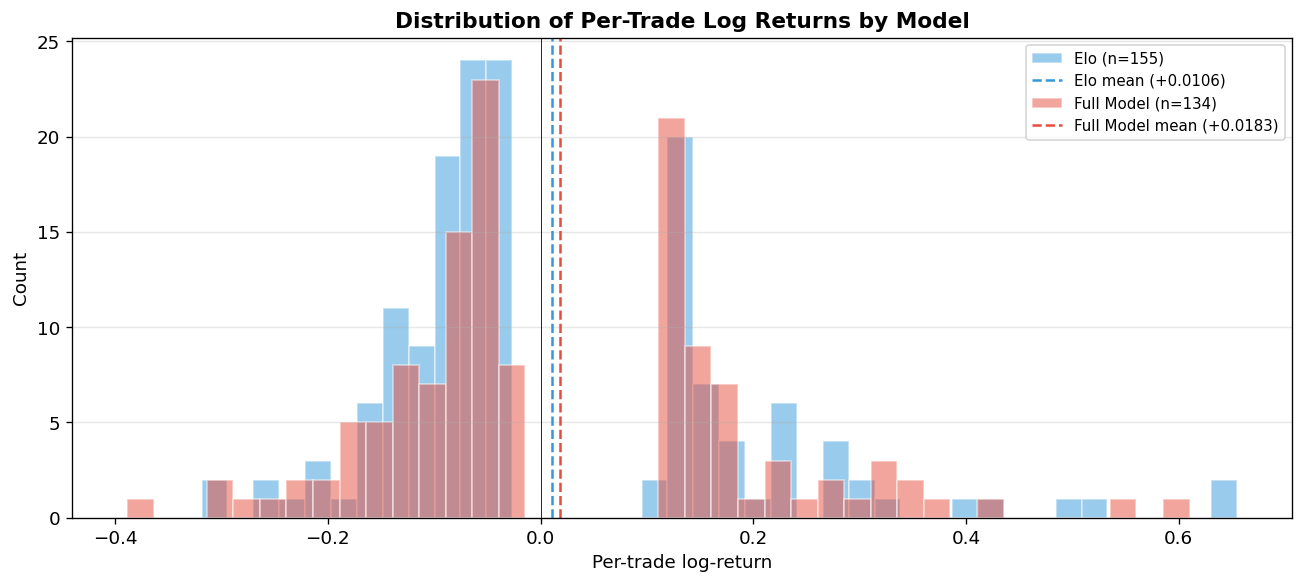

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
for name in ('elo', 'full_model'):
    lr = trades[name]['log_ret'].values
    ax.hist(lr, bins=40, alpha=0.5, color=MODEL_COLORS[name],
            edgecolor='white', label=f'{MODEL_LABELS[name]} (n={len(lr)})')
    ax.axvline(lr.mean(), color=MODEL_COLORS[name], ls='--', lw=1.5,
               label=f'{MODEL_LABELS[name]} mean ({lr.mean():+.4f})')
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Per-trade log-return')
ax.set_ylabel('Count')
ax.set_title('Distribution of Per-Trade Log Returns by Model', fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_fig(fig, 'sig_per_trade_log_return_distribution')
plt.show()